In [1]:
import pandas as pd

file_path = "./bint_batch_results.csv"

df = pd.read_csv(file_path, nrows=10)

print("\nColumn names:")
print(df.columns.tolist())

print("\nPandas data types:")
print(df.dtypes)

print("\nFirst 10 rows:")
print(df.head(10))


Column names:
['RunId', 'iteration', 'Step', 'size', 'num_drop_offs', 'agent_vision_radius', 'num_delivery', 'num_map_malicious', 'rng', 'Ledger Size', 'AgentID', 'Agent Type', 'State', 'Points', 'Deliveries', 'Global Trust', 'Positive TNFTs', 'Negative TNFTs', 'Map Size', 'Known Drop-Offs', 'Steps on Package']

Pandas data types:
RunId                    int64
iteration                int64
Step                   float64
size                       str
num_drop_offs            int64
agent_vision_radius      int64
num_delivery             int64
num_map_malicious        int64
rng                      int64
Ledger Size              int64
AgentID                  int64
Agent Type                 str
State                      str
Points                   int64
Deliveries               int64
Global Trust           float64
Positive TNFTs           int64
Negative TNFTs           int64
Map Size                 int64
Known Drop-Offs          int64
Steps on Package         int64
dtype: object



In [2]:
optimized_dtypes = {
    "RunId": "int16",
    "iteration": "int16",
    "Step": "int16",
    "size": "str",
    "num_drop_offs": "int16",
    "agent_vision_radius": "int16",
    "num_delivery": "int16",
    "num_map_malicious": "int16",
    "rng": "int64",
    "Ledger Size": "int32",
    "AgentID": "int16",
    "Agent Type": "category",
    "State": "category",
    "Points": "float32",
    "Deliveries": "int16",
    "Global Trust": "float32",
    "Positive TNFTs": "int16",
    "Negative TNFTs": "int16",
    "Map Size": "int16",
    "Known Drop-Offs": "int16",
    "Steps on Package": "int16",
}

df = pd.read_csv("./bint_batch_results.csv", dtype=optimized_dtypes)
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 39639600 entries, 0 to 39639599
Data columns (total 21 columns):
 #   Column               Dtype   
---  ------               -----   
 0   RunId                int16   
 1   iteration            int16   
 2   Step                 int16   
 3   size                 str     
 4   num_drop_offs        int16   
 5   agent_vision_radius  int16   
 6   num_delivery         int16   
 7   num_map_malicious    int16   
 8   rng                  int64   
 9   Ledger Size          int32   
 10  AgentID              int16   
 11  Agent Type           category
 12  State                category
 13  Points               float32 
 14  Deliveries           int16   
 15  Global Trust         float32 
 16  Positive TNFTs       int16   
 17  Negative TNFTs       int16   
 18  Map Size             int16   
 19  Known Drop-Offs      int16   
 20  Steps on Package     int16   
dtypes: category(2), float32(2), int16(14), int32(1), int64(1), str(1)
memory usage: 4.0 GB

In [3]:
# might keep width and height in the future, only dropping cause they're static for this batch
cols_to_drop = ["size", "agent_vision_radius", "rng"]
df.drop(columns=cols_to_drop, inplace=True)
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 39639600 entries, 0 to 39639599
Data columns (total 18 columns):
 #   Column             Dtype   
---  ------             -----   
 0   RunId              int16   
 1   iteration          int16   
 2   Step               int16   
 3   num_drop_offs      int16   
 4   num_delivery       int16   
 5   num_map_malicious  int16   
 6   Ledger Size        int32   
 7   AgentID            int16   
 8   Agent Type         category
 9   State              category
 10  Points             float32 
 11  Deliveries         int16   
 12  Global Trust       float32 
 13  Positive TNFTs     int16   
 14  Negative TNFTs     int16   
 15  Map Size           int16   
 16  Known Drop-Offs    int16   
 17  Steps on Package   int16   
dtypes: category(2), float32(2), int16(13), int32(1)
memory usage: 1.5 GB


In [4]:
missing_data = df.isna().sum()
print(missing_data)

RunId                0
iteration            0
Step                 0
num_drop_offs        0
num_delivery         0
num_map_malicious    0
Ledger Size          0
AgentID              0
Agent Type           0
State                0
Points               0
Deliveries           0
Global Trust         0
Positive TNFTs       0
Negative TNFTs       0
Map Size             0
Known Drop-Offs      0
Steps on Package     0
dtype: int64


In [5]:
group_cols = ["iteration", "Step", "num_map_malicious", "num_drop_offs", "num_delivery", "Agent Type"]

metrics_to_mean = ["Global Trust", "Points", "Map Size", "Positive TNFTs", "Negative TNFTs"]
metrics_to_sum = ["Deliveries"]

df_mean = df.groupby(group_cols, observed=True)[metrics_to_mean].mean().reset_index()
df_sum = df.groupby(group_cols, observed=True)[metrics_to_sum].sum().reset_index()

agg_df = pd.merge(df_mean, df_sum, on=group_cols)
agg_df.to_csv("bint_run_level_summary.csv", index=False)

del df_mean
del df_sum

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

--- PHASE 4: VISUALIZATION ---


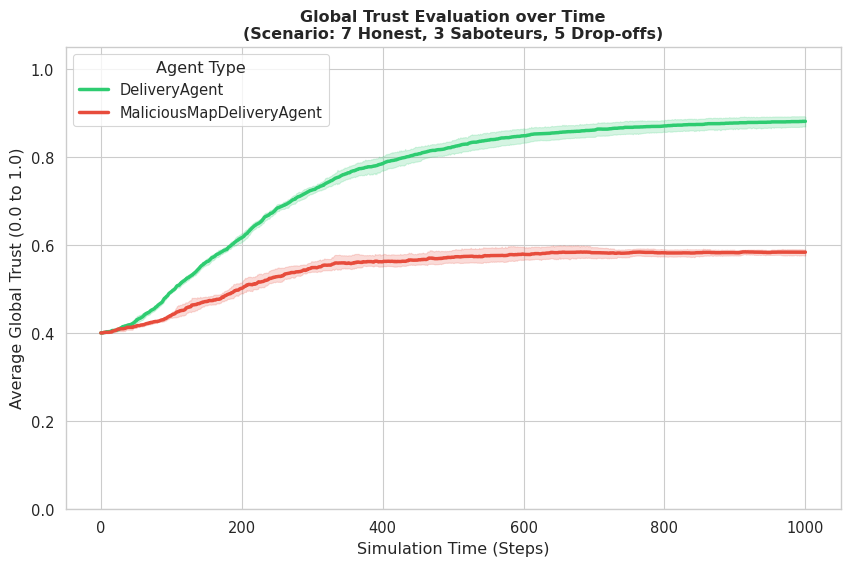

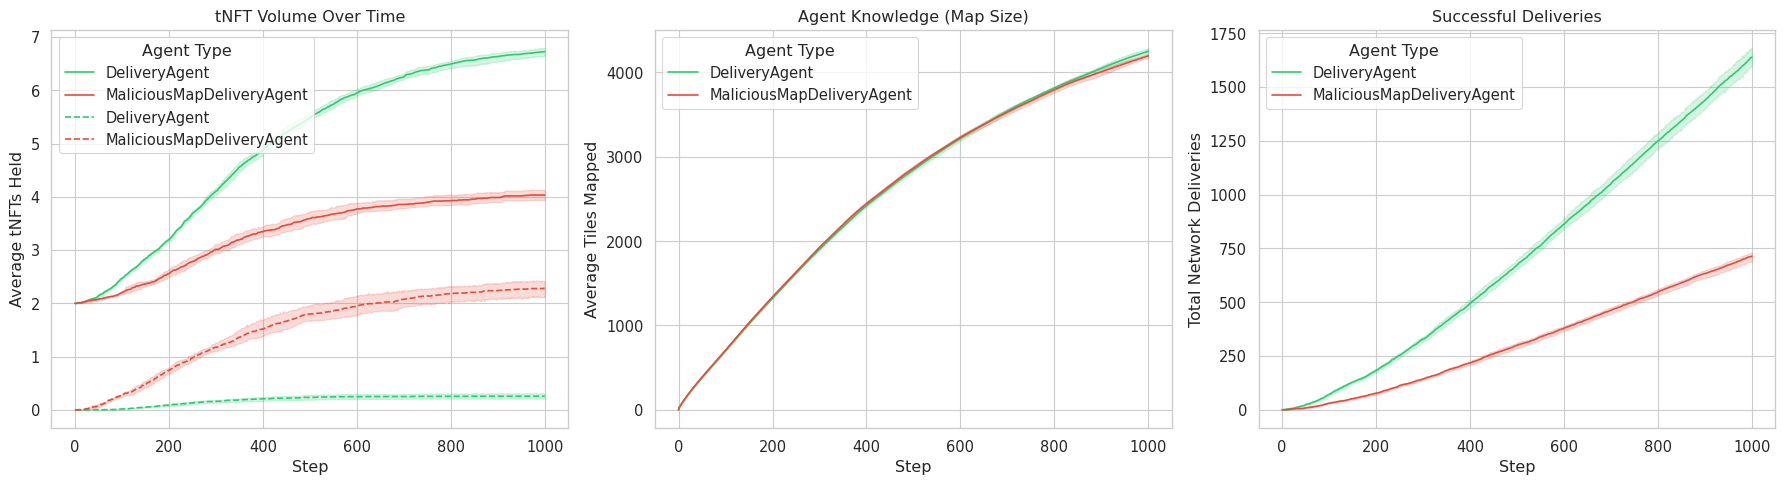

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

print("--- PHASE 4: VISUALIZATION ---")

# 1. Define the scenario slice ONCE
scenario_df = agg_df[
    (agg_df['num_drop_offs'] == 5) &
    (agg_df['num_delivery'] == 7) &
    (agg_df['num_map_malicious'] == 3)
]

# ---------------------------------------------------
# GRAPH 1: TRUST DYNAMICS
# ---------------------------------------------------
plt.figure(figsize=(10,6))
sns.lineplot(
    data=scenario_df,
    x="Step",
    y="Global Trust",
    hue="Agent Type",
    palette=["#2ecc71", "#e74c3c"],
    linewidth=2.5
)
plt.title("Global Trust Evaluation over Time\n(Scenario: 7 Honest, 3 Saboteurs, 5 Drop-offs)", weight='bold')
plt.ylabel("Average Global Trust (0.0 to 1.0)")
plt.xlabel("Simulation Time (Steps)")
plt.ylim(0, 1.05)
plt.show()

# ---------------------------------------------------
# GRAPH 2: DIAGNOSTIC DASHBOARD
# ---------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: The TNFT Economy
sns.lineplot(data=scenario_df, x="Step", y="Positive TNFTs", hue="Agent Type", palette=["#2ecc71", "#e74c3c"], ax=axes[0])
sns.lineplot(data=scenario_df, x="Step", y="Negative TNFTs", hue="Agent Type", palette=["#2ecc71", "#e74c3c"], linestyle="--", ax=axes[0])
axes[0].set_title("tNFT Volume Over Time")
axes[0].set_ylabel("Average tNFTs Held")

# Plot B: Knowledge Accumulation
sns.lineplot(data=scenario_df, x="Step", y="Map Size", hue="Agent Type", palette=["#2ecc71", "#e74c3c"], ax=axes[1])
axes[1].set_title("Agent Knowledge (Map Size)")
axes[1].set_ylabel("Average Tiles Mapped")

# Plot C: Actual Deliveries
sns.lineplot(data=scenario_df, x="Step", y="Deliveries", hue="Agent Type", palette=["#2ecc71", "#e74c3c"], ax=axes[2])
axes[2].set_title("Successful Deliveries")
axes[2].set_ylabel("Total Network Deliveries")

plt.tight_layout()
plt.show()

--- SCENARIO COMPARISON: STRESS TESTING ---


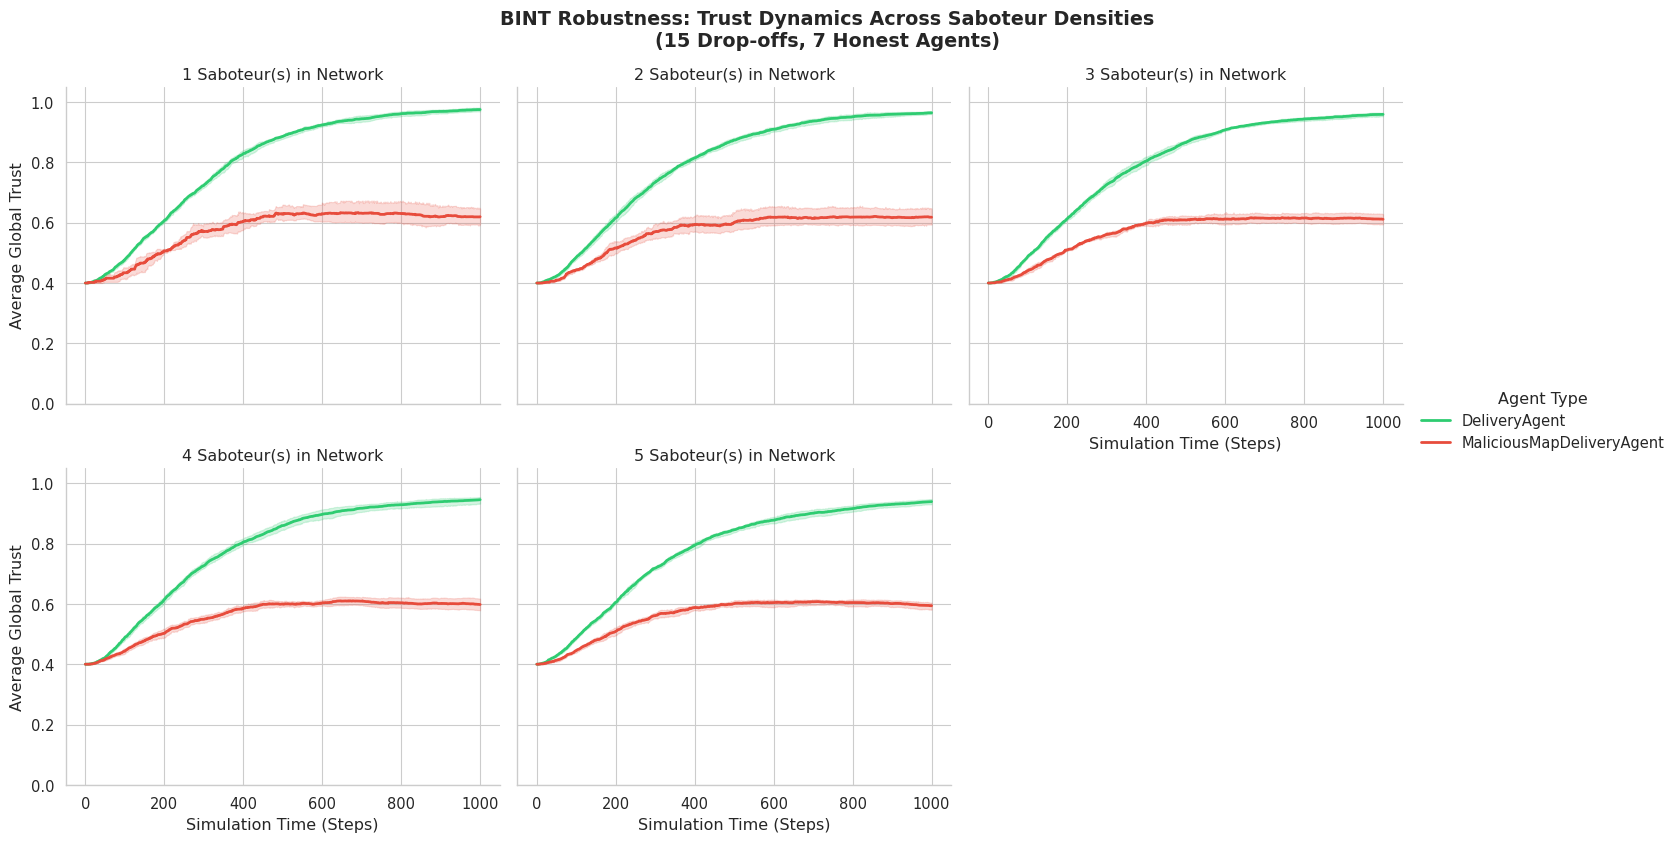

In [10]:
print("--- SCENARIO COMPARISON: STRESS TESTING ---")

# 1. Lock the environment variables, but keep ALL malicious counts
# Let's look at 10 drop-offs and 7 honest agents
stress_test_df = agg_df[
    (agg_df['num_drop_offs'] == 15) & 
    (agg_df['num_delivery'] == 7) &
    (agg_df['num_map_malicious'] > 0) # Ignore the 0 saboteur baseline for this specific plot
]

# 2. Create the Facet Grid (Side-by-side plots)
g = sns.relplot(
    data=stress_test_df,
    x="Step",
    y="Global Trust",
    hue="Agent Type",
    col="num_map_malicious", # This is the magic parameter! It creates a new graph for each value.
    col_wrap=3,              # 3 graphs per row
    kind="line",
    palette=["#2ecc71", "#e74c3c"],
    height=4, 
    aspect=1.2,
    linewidth=2
)

# 3. Format the grid for your thesis
g.fig.suptitle("BINT Robustness: Trust Dynamics Across Saboteur Densities\n(15 Drop-offs, 7 Honest Agents)", y=1.05, weight='bold')
g.set_axis_labels("Simulation Time (Steps)", "Average Global Trust")
g.set(ylim=(0, 1.05))

# Rename the subplot titles to look professional
for ax, title in zip(g.axes.flat, stress_test_df['num_map_malicious'].unique()):
    ax.set_title(f"{title} Saboteur(s) in Network")

plt.savefig("thesis_stress_test_grid.png", dpi=300, bbox_inches='tight')
plt.show()

--- SCENARIO COMPARISON: THROUGHPUT HEATMAP ---


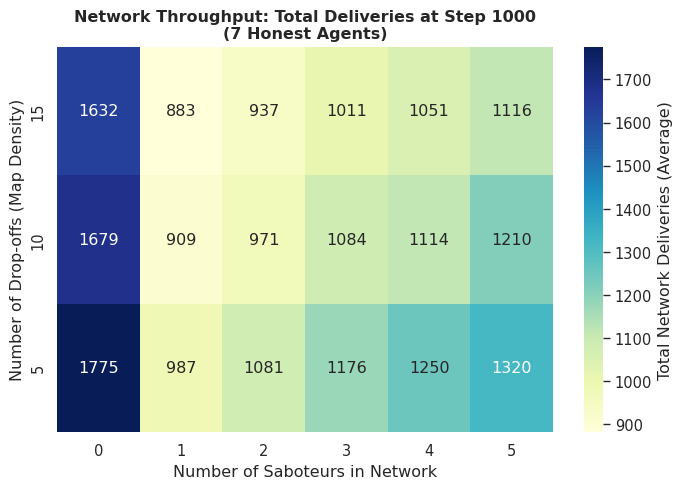

In [9]:
print("--- SCENARIO COMPARISON: THROUGHPUT HEATMAP ---")

# 1. We only care about the FINAL step (Step 1000) to see total deliveries
final_step_df = agg_df[agg_df['Step'] == 1000].copy()

# 2. We average the total deliveries across all 100 iterations for each scenario combination
# (Using 7 honest agents as our baseline)
heatmap_data = final_step_df[final_step_df['num_delivery'] == 7].groupby(
    ['num_drop_offs', 'num_map_malicious']
)['Deliveries'].mean().reset_index()

# 3. Pivot the table so Seaborn can draw a 2D Heatmap
heatmap_pivot = heatmap_data.pivot(
    index='num_drop_offs', 
    columns='num_map_malicious', 
    values='Deliveries'
)

# 4. Draw the Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    heatmap_pivot, 
    annot=True,       # Show the actual numbers in the boxes
    fmt=".0f",        # No decimal points for deliveries
    cmap="YlGnBu",    # Yellow to Green to Blue (Blue = High Deliveries)
    cbar_kws={'label': 'Total Network Deliveries (Average)'}
)

# 5. Format for the thesis
plt.title("Network Throughput: Total Deliveries at Step 1000\n(7 Honest Agents)", weight='bold')
plt.ylabel("Number of Drop-offs (Map Density)")
plt.xlabel("Number of Saboteurs in Network")
plt.gca().invert_yaxis() # Puts the highest drop-off count at the top

plt.savefig("thesis_throughput_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()